In [1]:
import os
import sys
sys.path.append('..')


In [2]:
from scripts.brent_analysis import (
    load_brent_data,
    plot_time_series,
    plot_rolling_mean,
    seasonal_decompose_plot,
    adf_test,
    compute_log_returns,
    plot_log_returns,
    compute_volatility,
    plot_volatility,
    plot_return_distribution,
    plot_autocorrelation
)


c:\Users\tsega\OneDrive\Documents\brent_crude_analysis\notebooks\..\scripts\brent_analysis.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(filepath, parse_dates=['Date'])


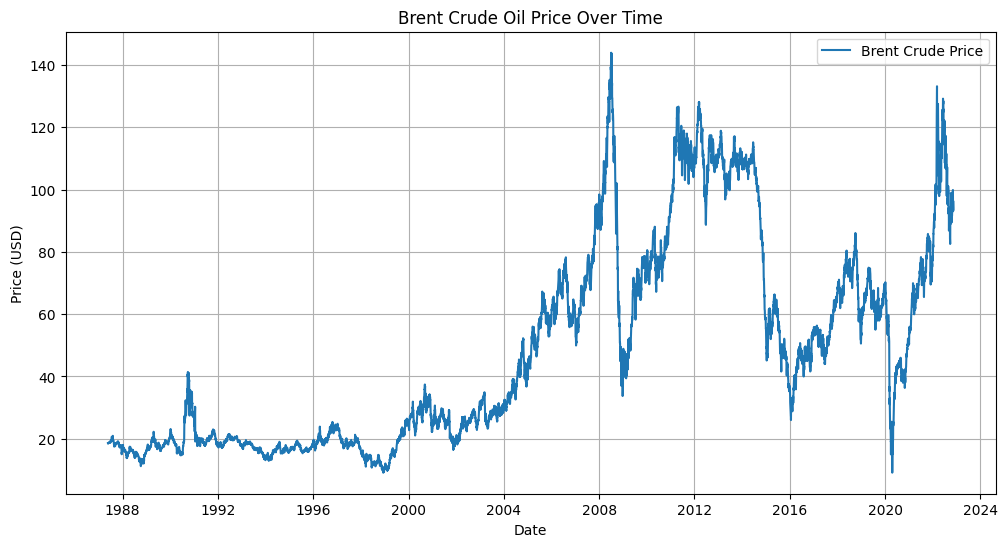

In [3]:

# Load dataset
df = load_brent_data('../data/raw/BrentOilPrices.csv')

# Plot time series
plot_time_series(df)

In [4]:
import numpy as np


df.sort_values("Date", inplace=True)
df.reset_index(drop=True, inplace=True)

# 2. Create log returns
df["log_return"] = np.log(df["Price"] / df["Price"].shift(1))

# 3. Calculate rolling volatility (e.g., 30-day rolling std of log returns)
df["volatility_30d"] = df["log_return"].rolling(window=30).std()

# 4. Drop NA values introduced by shift/rolling
df.dropna(inplace=True)

# 5. Save to new CSV
df.to_csv("../data/processed/brent_oil_with_log_and_volatility.csv", index=False)

# Preview
df.head()

,Price,log_return,volatility_30d
30,19.25,0.014125,0.006450
31,19.33,0.004147,0.006139
32,19.48,0.007730,0.006204
33,19.50,0.001026,0.006201
34,19.48,-0.001026,0.006219


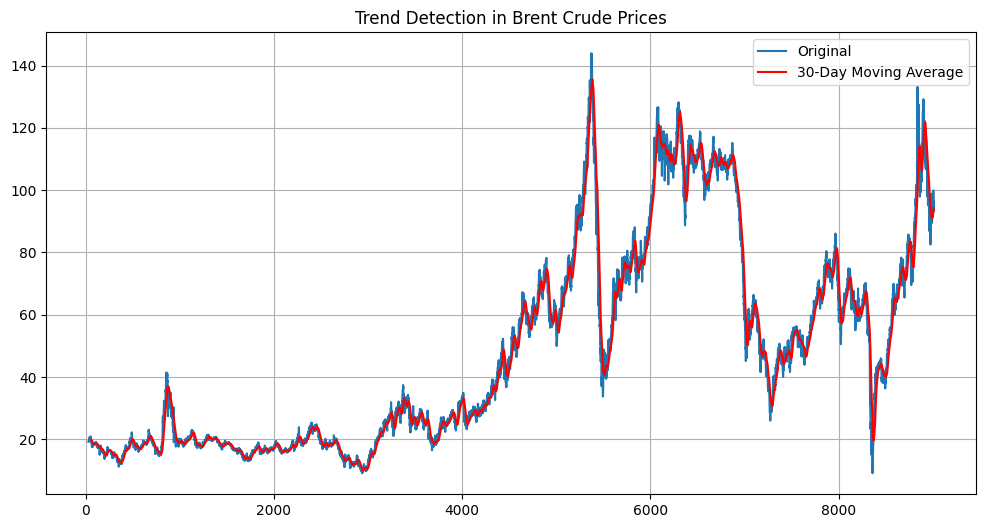

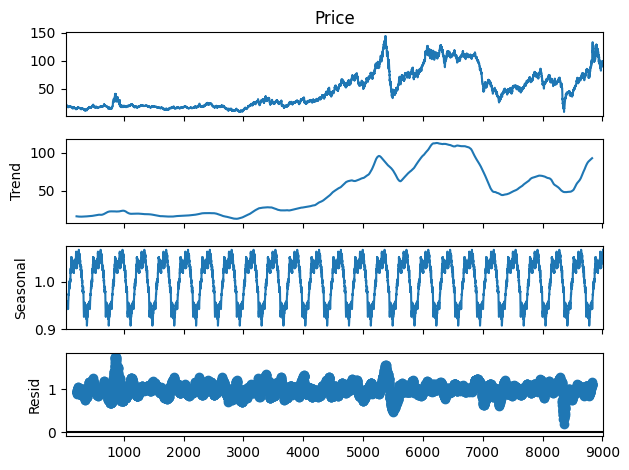

ADF Statistic: -1.9920117745729171
p-value: 0.2900866043540191
Critical Value (1%): -3.431080776037606
Critical Value (5%): -2.8618629553702966
Critical Value (10%): -2.5669419041246435
❌ The series is non-stationary (fail to reject H0).


In [5]:
# Plot rolling mean (trend)
plot_rolling_mean(df)

# Seasonal decomposition
seasonal_decompose_plot(df)

# ADF test for stationarity
adf_test(df)


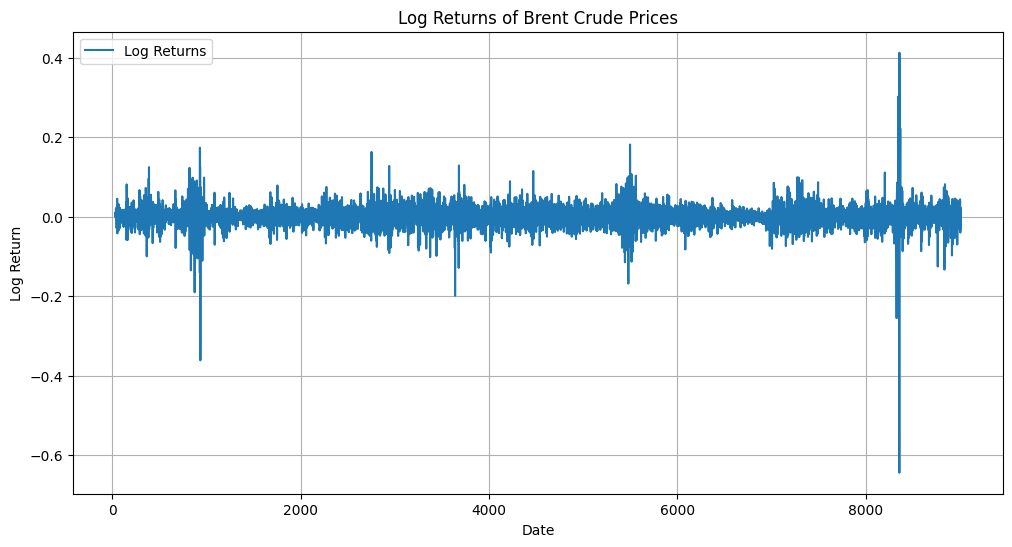

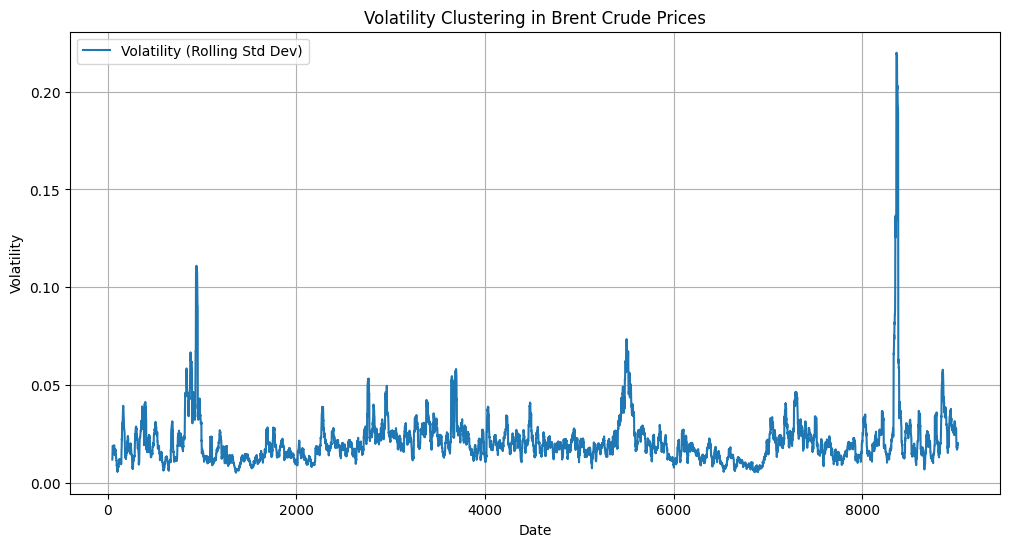

In [6]:
# Calculate log returns
df = compute_log_returns(df)

# Plot log returns
plot_log_returns(df)

# Calculate volatility (rolling std dev of log returns)
df = compute_volatility(df)

# Plot volatility clustering
plot_volatility(df)

# 📊 Change Point Analysis of Brent Oil Prices

## 🧠 1. Understanding the Project Scope

This project analyzes Brent crude oil price time series data to detect **structural changes** or **"change points"** that may result from major global events such as geopolitical tensions, economic sanctions, or global crises. The core objective is to understand *when* significant shifts occurred in oil price behavior and how they align with real-world events.

---

## 📚 2. Key References

To carry out this project effectively, the following references provide essential background:

- [Ruptures: A Python Library for Change Point Detection](https://centre-borelli.github.io/ruptures-docs/)
- [Time Series Analysis in Python](https://www.statsmodels.org/stable/tsa.html)
- [Bayesian Change Point Models](https://www.tandfonline.com/doi/full/10.1080/01621459.1998.10474113)
- Historical oil market events from [IEA](https://www.iea.org/) or [Investopedia](https://www.investopedia.com/)

---

## 🔍 3. Time Series Properties Analysis

Before modeling, the Brent oil price time series was examined for key statistical properties:

### 🔸 a. Trend
- The data shows a long-term **upward trend** until the mid-2010s, followed by sharp drops and rebounds.
- Indicative of **non-stationarity**, which affects model selection.

### 🔸 b. Seasonality
- Oil prices may exhibit **yearly or event-driven seasonality** based on demand cycles or political changes.

### 🔸 c. Stationarity (Augmented Dickey-Fuller Test)

```text
ADF Statistic: -1.99
p-value: 0.289
Critical Values:
  1%: -3.43
  5%: -2.86
 10%: -2.57
Result: ❌ The series is **non-stationary** (fail to reject H0).


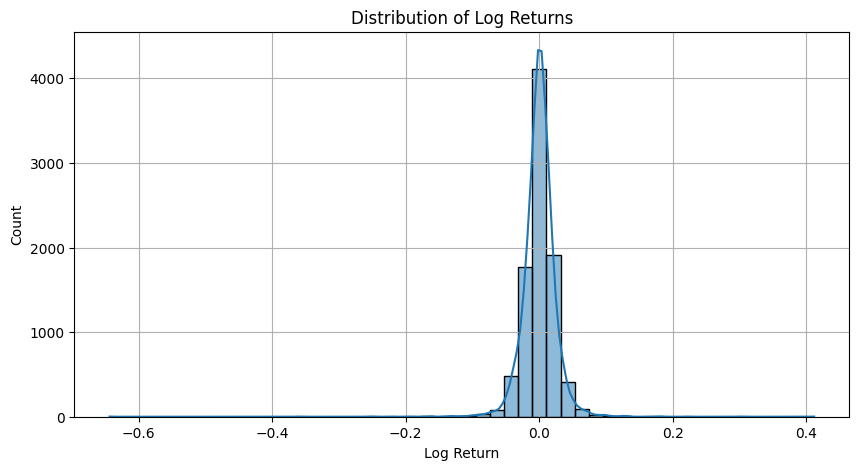

In [7]:
plot_return_distribution(df)


The histogram of log returns helps understand the distribution of price changes. In financial time series, returns often deviate from a normal distribution — they may have heavy tails and skewness, which is important to know for risk modeling.

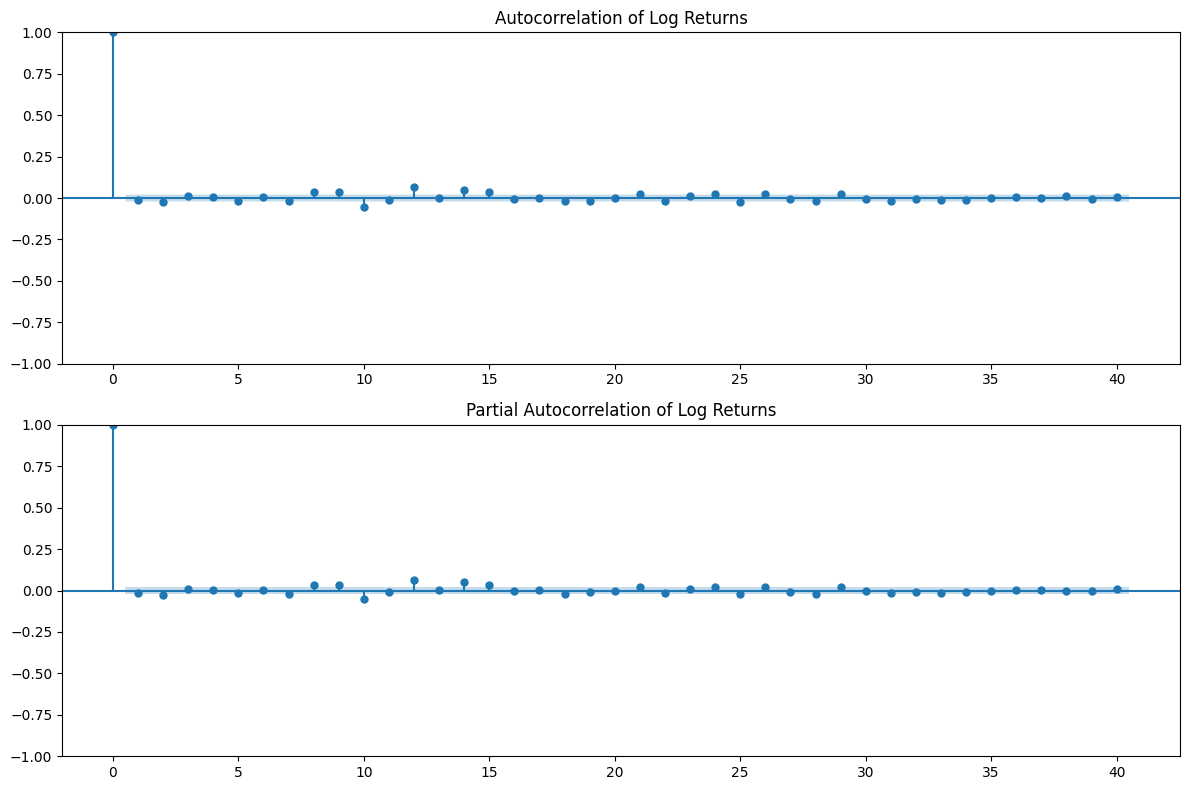

In [8]:
plot_autocorrelation(df)

The autocorrelation function (ACF) and partial autocorrelation function (PACF) plots help detect time dependencies. If significant lags are observed, this suggests that past price movements affect future ones — an important insight for ARIMA or GARCH modeling.

## 🔍 Summary of Findings (Task 1)

- The Brent crude oil price series shows a clear trend and seasonality — visualized via rolling mean and decomposition.
- The ADF test indicates the series is **non-stationary** (p-value > 0.05), so differencing or transformation will be needed for modeling.
- Log returns were calculated to stabilize variance and better understand daily changes.
- Volatility clustering was detected via rolling standard deviation — a typical pattern in financial time series.
- Histogram of returns shows **non-normal distribution**, implying the need for robust models that handle fat tails.
- ACF/PACF plots of returns indicate some **autocorrelation structure**, useful for choosing appropriate time series models later.
